# 11. Model Explainability using SHAP

## 11.1 Import Libraries

This section imports the libraries required for loading the trained LightGBM model, preparing the evaluation dataset, and interpreting model predictions using SHAP.

The imported libraries support:

- Data manipulation
- Model loading
- SHAP explainability
- Data visualization

In [2]:
# ============================================================
# Model Explainability using SHAP
# Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Model Loading
import joblib

# Data Splitting
from sklearn.model_selection import train_test_split

# SHAP
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

e:\pta\envs\creditrisk\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries Imported Successfully


## 11.2 Load the Selected LightGBM Model

In this section, the selected LightGBM model is loaded from disk. The model was previously trained, evaluated, and identified as the best-performing algorithm based on ROC-AUC and Precision-Recall AUC.

Loading the saved model ensures reproducibility and allows explainability analysis without retraining the model.

In [3]:
# ============================================================
# Load Selected LightGBM Model
# ============================================================

lightgbm_model = joblib.load("../models/lightgbm.pkl")

print("=" * 60)
print("LightGBM Model Loaded Successfully")
print("=" * 60)

print(lightgbm_model)

LightGBM Model Loaded Successfully
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SK_ID_CURR', 'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
              

## 11.3 Load the Engineered Dataset

The engineered dataset is loaded to recreate the same evaluation dataset used during model training and evaluation. Using identical input data ensures that the SHAP explanations accurately reflect the behaviour of the selected LightGBM model.

In [4]:
# ============================================================
# Load Engineered Dataset
# ============================================================

df = pd.read_csv("../data/processed/application_train_engineered.csv")

print("=" * 60)
print("Engineered Dataset Loaded Successfully")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

df.head()

Engineered Dataset Loaded Successfully
Dataset Shape : (307511, 146)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,REGISTRATION_YEARS,ID_PUBLISH_YEARS,PHONE_CHANGE_YEARS,EMPLOYMENT_YEARS,HAS_EMPLOYMENT_INFO,INCOME_PER_EMPLOYMENT_YEAR,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,INCOME_PER_FAMILY_MEMBER,INCOME_PER_CHILD,EMPLOYMENT_AGE_RATIO,EMPLOYMENT_CATEGORY,CREDIT_TERM,LOAN_GOODS_RATIO,AVG_EXT_SOURCE,EXT_RISK_CATEGORY,AGE_CATEGORY,ID_CHANGE_YEARS,INCOME_EMPLOYMENT_SCORE,CREDIT_EMPLOYMENT_SCORE,INCOME_EXT_SOURCE_SCORE,CREDIT_EXT_SOURCE_SCORE
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637.0000,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,25.9000,9.9945,5.8042,3.1068,1.7400,1,116379.3103,2.0079,0.1220,16.4611,202500.0000,202500.0000,0.0672,0-2 Years,16.4611,1.1584,0.1618,Very High Risk,26-35,5.8082,13604.2471,27315.8166,32761.8911,65782.2372
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188.0000,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,0.5353,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0

## 11.4 Recreate the Test Dataset

To ensure consistency with the model training and evaluation process, the same train-test split used in previous notebooks is recreated.

Using an identical test dataset guarantees that SHAP explanations correspond to the predictions generated by the selected LightGBM model.

In [5]:
# ============================================================
# Recreate Train-Test Split
# ============================================================

TARGET_COLUMN = "TARGET"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Train-Test Split Recreated Successfully")
print("=" * 60)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Number of Features : {X_test.shape[1]}")

Train-Test Split Recreated Successfully
Training Samples : 246008
Testing Samples  : 61503
Number of Features : 145


### Business Interpretation

Recreating the original train-test split ensures that the SHAP explainability analysis is performed on the same unseen borrower data used during model evaluation. This maintains consistency between model validation and interpretation, ensuring that the insights generated accurately reflect the model's behaviour under real-world credit risk assessment conditions.

## 11.5 Initialize SHAP Explainer

SHAP (SHapley Additive exPlanations) is used to explain how individual features contribute to the predictions generated by the selected LightGBM model.

In this section, the fitted preprocessing pipeline is applied to the test dataset, and a SHAP TreeExplainer is initialized for the trained LightGBM classifier. SHAP values are then computed for the transformed test data, forming the basis for the explainability analyses in the following sections.

In [6]:
# ============================================================
# Prepare Data for SHAP Analysis
# ============================================================

# Extract fitted preprocessor and classifier
preprocessor = lightgbm_model.named_steps["preprocessor"]
classifier = lightgbm_model.named_steps["classifier"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

print("=" * 60)
print("Test Data Transformed Successfully")
print("=" * 60)

print(f"Transformed Shape : {X_test_transformed.shape}")

# ============================================================
# Initialize SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(classifier)

shap_values = explainer.shap_values(X_test_transformed)

print("=" * 60)
print("SHAP Values Computed Successfully")
print("=" * 60)

Test Data Transformed Successfully
Transformed Shape : (61503, 280)
SHAP Values Computed Successfully


### Business Interpretation

SHAP enhances model transparency by quantifying the contribution of each feature to individual loan default predictions. This enables financial institutions to understand not only the predicted outcome but also the underlying factors influencing the decision. Such explainability supports regulatory compliance, improves stakeholder confidence, and promotes fair and accountable AI-driven credit risk assessment.

## 11.6 Global Feature Importance (SHAP Summary Plot)

The SHAP Summary Plot provides a global explanation of the LightGBM model by showing how each feature contributes to predictions across the entire test dataset.

Each point represents an individual borrower.

The plot simultaneously displays:

- Overall feature importance
- Direction of feature impact
- Distribution of SHAP values
- Relationship between feature values and prediction outcomes

Features appearing at the top of the plot have the greatest overall influence on loan default prediction.

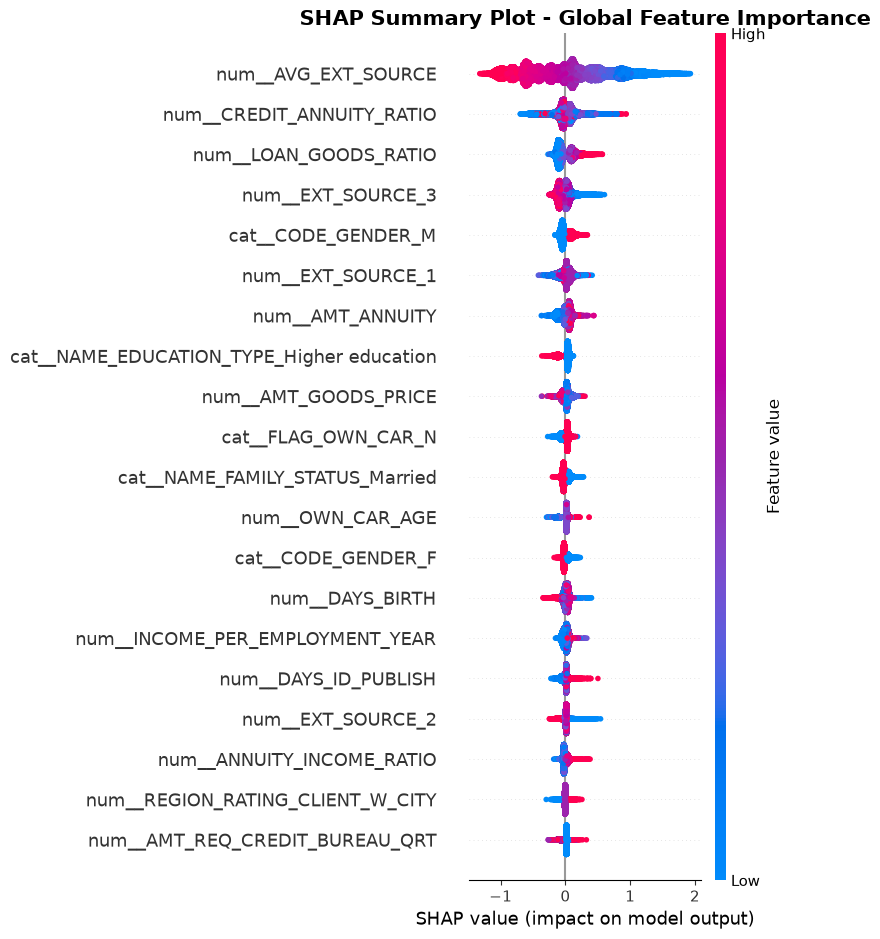

In [13]:
# ============================================================
# SHAP Summary Plot
# ============================================================

# Handle different SHAP versions
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.title(
    "SHAP Summary Plot - Global Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Business Interpretation

The SHAP Summary Plot provides a comprehensive explanation of how the LightGBM model predicts loan default risk across the entire borrower population.

The analysis shows that external credit bureau scores, particularly the average external score (AVG_EXT_SOURCE), are the strongest determinants of default prediction. Higher external credit scores generally reduce the predicted probability of default, while lower scores increase the estimated credit risk. Engineered financial variables such as Credit-to-Annuity Ratio and Loan-to-Goods Ratio also rank among the most influential predictors, demonstrating that the feature engineering process successfully enhanced the model's ability to capture borrower risk.

From a business perspective, the SHAP analysis confirms that the model bases its decisions on meaningful financial and credit-related characteristics rather than arbitrary patterns. This improves transparency, supports regulatory compliance, and enables financial institutions to justify automated lending decisions using interpretable evidence.

## 11.7 SHAP Bar Plot (Mean Absolute SHAP Values)

The SHAP Bar Plot summarizes the average absolute contribution of each feature to the model's predictions across the entire test dataset.

Unlike the SHAP Summary Plot, which illustrates both the magnitude and direction of feature effects, the SHAP Bar Plot focuses solely on the overall importance of each feature.

Features with larger mean absolute SHAP values have a greater overall influence on the model's prediction of loan default risk.

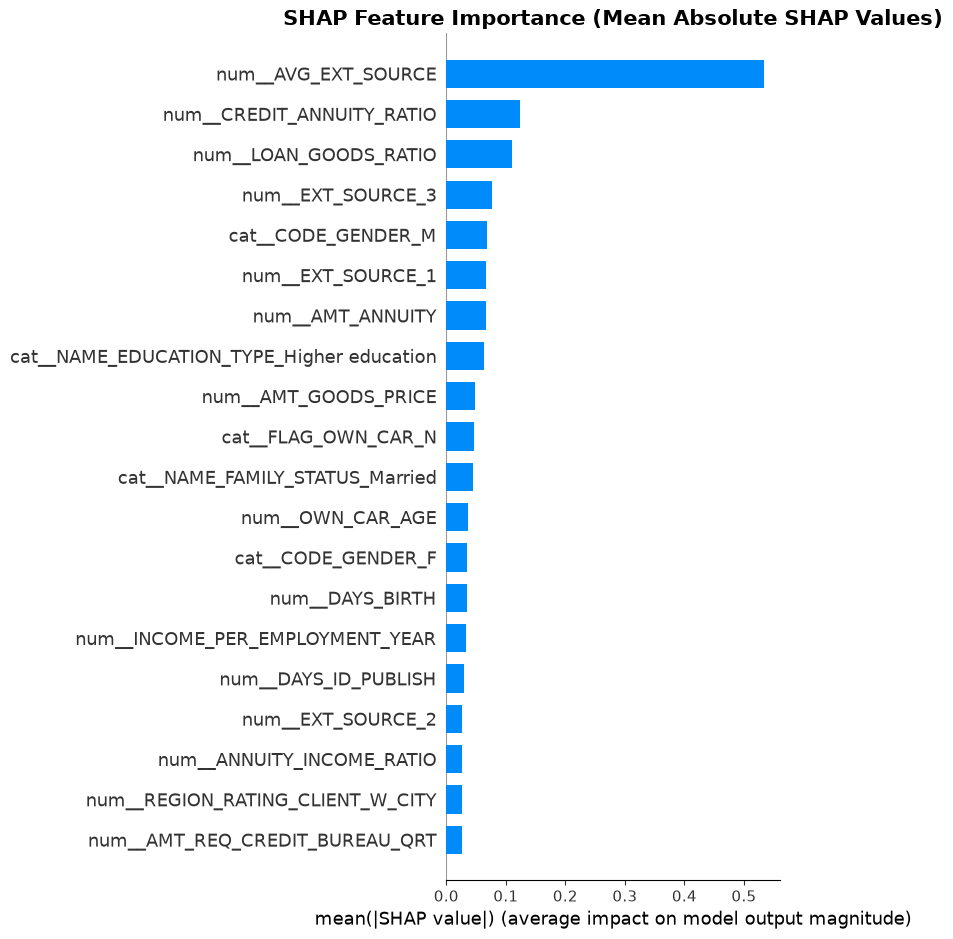

In [15]:
# ============================================================
# SHAP Bar Plot (Global Feature Importance)
# ============================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "SHAP Feature Importance (Mean Absolute SHAP Values)",
    fontsize=15,
    fontweight="bold"
)
    
plt.tight_layout()

plt.show()

### Business Interpretation

The SHAP Bar Plot ranks features according to their average contribution to the LightGBM model's predictions across all borrowers.

The results indicate that the average external credit score (AVG_EXT_SOURCE) is the most influential predictor of loan default risk, highlighting the importance of historical credit behaviour in assessing borrower reliability. Engineered financial variables, particularly Credit-to-Annuity Ratio and Loan-to-Goods Ratio, also rank among the top predictors, demonstrating that the feature engineering process significantly improved the model's ability to capture repayment risk.

Compared with the traditional feature importance analysis, the SHAP Bar Plot provides a more reliable measure of feature influence because it quantifies the average impact of each variable on model predictions. This enables financial institutions to better understand the primary drivers of credit risk, strengthen model transparency, and support explainable AI in lending decisions.

## 11.8 SHAP Dependence Plot

The SHAP Dependence Plot illustrates how changes in the value of an individual feature influence the model's prediction.

Unlike the global feature importance plots, this visualization focuses on a single feature and shows the relationship between its actual values and the corresponding SHAP values across all borrowers.

Each point represents an individual borrower. The position of the point indicates how the selected feature contributes to increasing or decreasing the predicted probability of loan default.

This analysis helps identify non-linear relationships, threshold effects, and interactions captured by the LightGBM model.

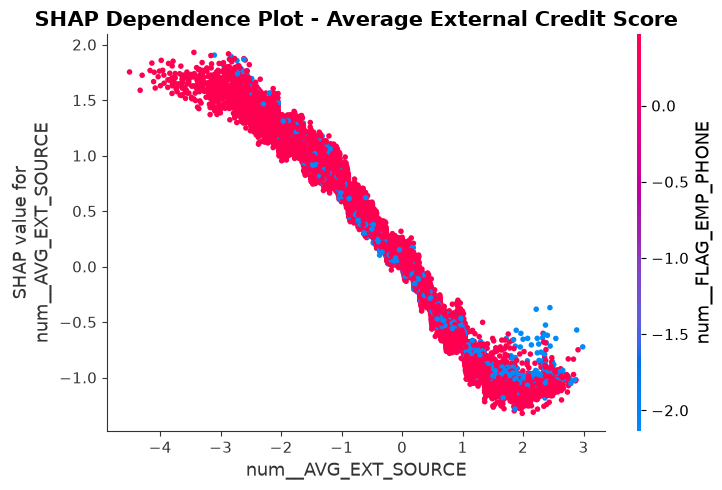

In [18]:
# ============================================================
# SHAP Dependence Plot
# ============================================================

# Feature to explain
feature_name = "num__AVG_EXT_SOURCE"



shap.dependence_plot(
    feature_name,
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependence Plot - Average External Credit Score",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Business Interpretation

The SHAP Dependence Plot demonstrates how changes in the average external credit score influence the predicted probability of loan default.

Borrowers with lower average external credit scores generally exhibit positive SHAP values, indicating an increased contribution to default risk. Conversely, borrowers with higher external credit scores tend to have negative SHAP values, reflecting a lower predicted probability of default. The smooth non-linear pattern observed in the plot highlights the LightGBM model's ability to capture complex relationships between borrower characteristics and credit risk.

The colour gradient further suggests that the effect of the average external credit score may interact with organisational characteristics, indicating that borrower risk is influenced by combinations of multiple features rather than a single variable in isolation.

From a business perspective, this analysis confirms that historical credit information is one of the strongest determinants of loan repayment behaviour. Understanding how changes in external credit scores affect predicted risk enables financial institutions to make more informed lending decisions and supports transparent, explainable credit risk assessment.

## 11.9 Individual Prediction Explanation (SHAP Waterfall Plot)

While the previous SHAP visualizations explained the model's behaviour across the entire borrower population, this section explains the prediction for a single borrower.

The SHAP Waterfall Plot illustrates how individual features contribute to moving the model's prediction away from the baseline prediction toward the final predicted outcome.

Positive SHAP values increase the predicted probability of default, whereas negative SHAP values decrease the predicted probability of default.

This local explanation enhances transparency by showing exactly why the model produced a particular prediction for an individual applicant.

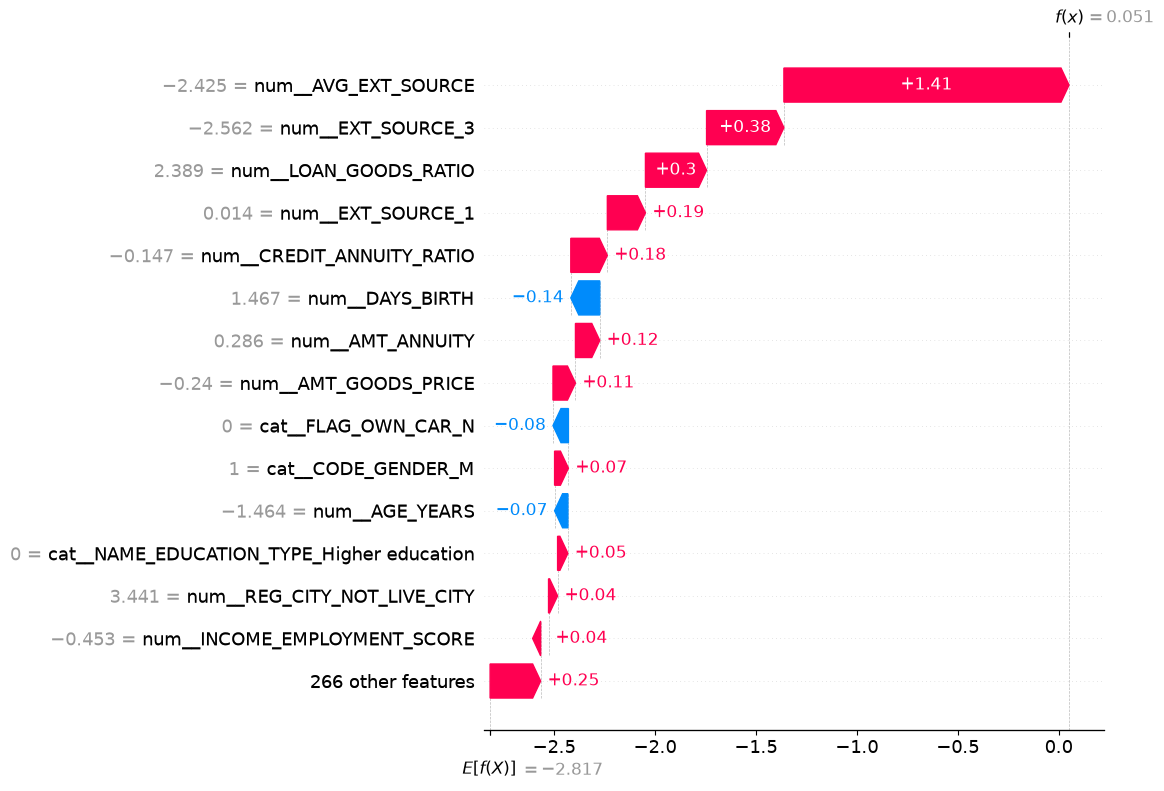

In [20]:
# ============================================================
# SHAP Waterfall Plot
# ============================================================

# Find the first borrower predicted as default
default_indices = np.where(lightgbm_model.predict(X_test) == 1)[0]

sample_index = default_indices[0]

# Handle different SHAP versions
if isinstance(shap_values, list):
    sample_shap_values = shap_values[1][sample_index]
else:
    sample_shap_values = shap_values[sample_index]

# Create SHAP Explanation object
explanation = shap.Explanation(
    values=sample_shap_values,
    base_values=explainer.expected_value,
    data=X_test_transformed[sample_index],
    feature_names=feature_names
)

# Plot Waterfall
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    explanation,
    max_display=15,
    show=False
)

plt.show()

### Business Interpretation

The SHAP Waterfall Plot explains the prediction for an individual borrower by showing how each feature contributes to the final credit risk assessment.

For the selected borrower, the model begins with a baseline prediction representing the average behaviour observed in the training data. Individual borrower characteristics then either increase or decrease the predicted risk. In this example, variables related to external credit scores and engineered financial ratios contribute most strongly to the final prediction, while features such as age and vehicle ownership partially offset the estimated risk.

From a business perspective, this local explanation enables financial institutions to understand the specific factors influencing an individual lending decision. Such transparency supports regulatory compliance, improves stakeholder confidence, and allows credit analysts to justify automated decisions using clear, feature-level evidence rather than relying solely on a model's final prediction.

## 11.10 Business Interpretation

The SHAP explainability analysis provides a comprehensive understanding of how the selected LightGBM model predicts loan default risk at both the global and individual borrower levels.

The global explainability results demonstrate that external credit bureau scores and engineered financial ratios are the most influential predictors of default risk. In particular, the average external credit score consistently emerged as the strongest contributor across multiple SHAP visualizations, highlighting the importance of historical credit behaviour in assessing borrower reliability. The prominence of engineered features such as Credit-to-Annuity Ratio and Loan-to-Goods Ratio further demonstrates that feature engineering enhanced the model's predictive capability.

The local explainability analysis illustrates how individual borrower characteristics contribute to a specific prediction. Rather than acting as a "black box," the model provides transparent explanations by quantifying the contribution of each feature to the final prediction. This enables analysts to understand why a borrower is classified as high or low risk and supports more informed credit decisions.

From a business perspective, SHAP significantly improves the transparency and trustworthiness of machine learning models in credit risk assessment. The ability to explain both global model behaviour and individual predictions supports regulatory compliance, strengthens stakeholder confidence, and facilitates responsible AI adoption in financial institutions. Such explainability is particularly valuable for justifying lending decisions, identifying key risk drivers, and ensuring that automated credit assessment remains interpretable and accountable.

## 11.11 Summary

In this notebook, the selected LightGBM model was interpreted using SHAP (SHapley Additive exPlanations) to improve the transparency and explainability of the credit risk prediction system.

The following explainability analyses were performed:

- Loaded the selected LightGBM model and engineered dataset.
- Recreated the original test dataset used during model evaluation.
- Initialized the SHAP TreeExplainer and computed SHAP values.
- Analysed global feature importance using the SHAP Summary Plot.
- Ranked the most influential variables using the SHAP Bar Plot.
- Examined the relationship between feature values and model predictions through the SHAP Dependence Plot.
- Explained an individual borrower's prediction using the SHAP Waterfall Plot.
- Interpreted the business implications of both global and local model explanations.

The SHAP analysis confirmed that external credit bureau scores and engineered financial ratios are the primary drivers of loan default prediction. These findings demonstrate that the LightGBM model makes predictions based on meaningful financial characteristics while maintaining a high degree of transparency and interpretability.

### Next Steps

In the next notebook (**Notebook 09 – Final Pipeline**), all preprocessing steps and the selected LightGBM model will be integrated into a complete prediction pipeline. The final notebook will demonstrate how new borrower data can be processed to generate loan default predictions, creating a deployment-ready credit risk prediction workflow.